# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dushyant1607/ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes
Purpose

The action queue ranks content for human review using observed decline signals and available performance data. A higher rank means a page should be reviewed sooner; it does not guarantee that updating the page will improve performance.

Reason codes

DECLINE_SIGNAL: The page is labelled as declining based on the observed 30-day impression trend.

HIGH_VISIBILITY: The page has meaningful impressions, so a review may protect existing search visibility.

STALE_CONTENT: The page has not been updated recently and may need a factual and relevance review.

THIN_CONTENT: The page may lack useful depth, but a reviewer must confirm this before recommending expansion.

LOW_CONFIDENCE: Available evidence is incomplete or conflicting; review manually before prioritizing action.

Archetype-to-action mapping

Content archetype

Suggested action

Declining with meaningful impressions

Review search intent, ranking changes, and snippet relevance first

Older content with existing visibility

Check outdated facts, examples, and missing subtopics

Thin content with meaningful visibility

Expand only where the topic has genuine information gaps

Low visibility with little evidence

Investigate indexing, demand, and measurement before investing in a rewrite

Conflicting or incomplete signals

Escalate for manual review; do not recommend an automatic change

Decay and refresh insight

The FlyRank research paper reports observational differences in content age and freshness. These findings support reviewing older or stale pages, particularly when they already have search visibility. They do not prove that age alone causes decline or that refreshing every page will improve performance.

Ranking and cost/value

Prioritize pages where a review could protect meaningful existing visibility and where the likely work is proportionate to the opportunity. Consider review effort, business importance, search demand, and the cost of editing. No financial return is assumed without measured evidence.

The queue is a decision-support tool, not an automatic content-editing or publishing system.

In [3]:
import numpy as np
import pandas as pd

queue = df.copy()

# Identify pages with declining impressions
queue["declining"] = queue["trend_direction"].astype(str).str.lower().eq("down")

# Add transparent reason codes
queue["reason_codes"] = ""

queue.loc[queue["declining"], "reason_codes"] += "DECLINE_SIGNAL;"

queue.loc[
    queue["impressions_90d"] >= queue["impressions_90d"].quantile(0.75),
    "reason_codes"
] += "HIGH_VISIBILITY;"

queue.loc[
    queue["days_since_last_update"] >= 180,
    "reason_codes"
] += "STALE_CONTENT;"

queue.loc[
    queue["word_count"] <= queue["word_count"].quantile(0.25),
    "reason_codes"
] += "THIN_CONTENT;"

# Rank declining pages with stronger existing visibility first
queue["priority_score"] = (
    queue["declining"].astype(int) * 2
    + (queue["impressions_90d"] / (queue["impressions_90d"].max() or 1))
    + (queue["days_since_last_update"].fillna(0) / 365)
)

queue["suggested_action"] = np.select(
    [
        queue["declining"] & (queue["days_since_last_update"] >= 180),
        queue["declining"] & (queue["word_count"] <= queue["word_count"].quantile(0.25)),
        queue["declining"],
    ],
    [
        "review_freshness_and_search_intent",
        "review_content_depth_and_search_intent",
        "review_rankings_and_snippet_relevance",
    ],
    default="monitor_or_review_manually",
)

# Keep only non-identifying fields in the export
export_columns = [
    "search_volume",
    "content_type",
    "main_intent",
    "word_count",
    "impressions_90d",
    "impressions_last_30d",
    "impressions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "trend_direction",
    "reason_codes",
    "suggested_action",
    "priority_score",
]

action_queue = (
    queue.sort_values("priority_score", ascending=False)
    [export_columns]
    .reset_index(drop=True)
)

action_queue.insert(0, "rank", range(1, len(action_queue) + 1))

print("Queue rows:", len(action_queue))
print("\nTop 10 recommended actions:")
display(action_queue.head(10))

print("\nReason-code counts:")
print(
    queue["reason_codes"]
    .str.rstrip(";")
    .str.split(";")
    .explode()
    .value_counts()
)

Queue rows: 30000

Top 10 recommended actions:


,rank,search_volume,content_type,main_intent,word_count,impressions_90d,impressions_last_30d,impressions_prev_30d,content_age_days,days_since_last_update,trend_direction,reason_codes,suggested_action,priority_score
0,1,1900.0,keyword article,informational,NaN,517715,120791,218786,537,104,down,DECLINE_SIGNAL;HIGH_VISIBILITY;,review_rankings_and_snippet_relevance,3.284932
1,2,70.0,keyword article,informational,2895.0,509252,89463,161284,445,20,down,DECLINE_SIGNAL;HIGH_VISIBILITY;,review_rankings_and_snippet_relevance,3.038448
2,3,0.0,keyword article,informational,NaN,35,3,26,374,373,down,DECLINE_SIGNAL;STALE_CONTENT;,review_freshness_and_search_intent,3.021985
3,4,0.0,keyword article,informational,NaN,2,0,2,373,373,down,DECLINE_SIGNAL;STALE_CONTENT;,review_freshness_and_search_intent,3.021922
4,5,0.0,keyword article,informational,NaN,2,0,2,372,372,down,DECLINE_SIGNAL;STALE_CONTENT;,review_freshness_and_search_intent,3.019182
5,6,590.0,keyword article,commercial,NaN,347399,104248,164079,362,104,down,DECLINE_SIGNAL;HIGH_VISIBILITY;,review_rankings_and_snippet_relevance,2.955955
6,7,40.0,keyword article,informational,3097.0,463103,83723,125416,445,20,down,DECLINE_SIGNAL;HIGH_VISIBILITY;,review_rankings_and_snippet_relevance,2.949308
7,8,NaN,keyword article,NaN,1277.0,52,9,31,335,335,down,DECLINE_SIGNAL;STALE_CONTENT;THIN_CONTENT;,review_freshness_and_search_intent,2.917909
8,9,NaN,keyword article,NaN,1246.0,30,6,22,334,334,down,DECLINE_SIGNAL;STALE_CONTENT;THIN_CONTENT;,review_freshness_and_search_intent,2.915126
9,10,70.0,keyword article,transactional,2761.0,309910,72468,124500,126,104,down,DECLINE_SIGNAL;HIGH_VISIBILITY;,review_rankings_and_snippet_relevance,2.883543



Reason-code counts:
reason_codes
DECLINE_SIGNAL     16262
                    7792
HIGH_VISIBILITY     7500
THIN_CONTENT        5576
STALE_CONTENT        174
Name: count, dtype: int64


## 2. Intended use and limits

### Intended use
This playbook helps SEO analysts prioritize content pages for manual review using observed impression trends, content age, and available performance metrics. It supports review prioritization, not guaranteed predictions of future performance.

### Limits
The dataset is observational and uses a 30-day impression trend as the decline label. Results may not generalize to future periods or unseen clients. Correlation does not establish causation, and the model does not prove that refreshing content will improve performance. Business value and actual post-update outcomes require separate measurement.

In [4]:
print("Intended users: SEO analysts and content strategists")
print("Purpose: prioritize pages for human review")
print("Target: observed 30-day impression trend")
print("Validation: random row split may overestimate generalization")
print("Limitation: client-grouped validation gave lower Precision@50")
print("Caution: observed associations do not prove causation")
print("Decision rule: human approval is required before any content change")

Intended users: SEO analysts and content strategists
Purpose: prioritize pages for human review
Target: observed 30-day impression trend
Validation: random row split may overestimate generalization
Limitation: client-grouped validation gave lower Precision@50
Caution: observed associations do not prove causation
Decision rule: human approval is required before any content change


## 3. Human review + the no-go list

### Human review
Before acting, a human reviewer must verify search intent, current rankings, factual accuracy, content quality, business relevance, and whether the available data supports the recommendation. Review the expected benefit against the time and cost of making changes.

### No-go list
Never automatically rewrite, delete, publish, or change prices or factual claims on a page. Do not make decisions solely from a model score, infer causation from correlation, or expose client identities, URLs, or private search queries. All recommendations require human approval.

In [5]:
review_checklist = [
    "Verify search intent and current rankings",
    "Check factual accuracy and content quality",
    "Confirm business relevance and expected value",
    "Review evidence before approving recommendations",
]

no_go_list = [
    "Automatically rewrite or publish content",
    "Automatically delete pages",
    "Make decisions solely from model scores",
    "Expose client IDs, URLs, or private queries",
]

print("HUMAN REVIEW CHECKLIST")
for item in review_checklist:
    print("-", item)

print("\nNO-GO LIST")
for item in no_go_list:
    print("-", item)


HUMAN REVIEW CHECKLIST
- Verify search intent and current rankings
- Check factual accuracy and content quality
- Confirm business relevance and expected value
- Review evidence before approving recommendations

NO-GO LIST
- Automatically rewrite or publish content
- Automatically delete pages
- Make decisions solely from model scores
- Expose client IDs, URLs, or private queries


## 4. Monitoring / retrain triggers

### Monitoring
Monitor the action queue over time by tracking the decline rate, Precision@50, and the distribution of recommended actions. Compare recommendations with actual outcomes after human-approved content updates.

### Retrain or review triggers
- **Performance drop:** Reassess the model if Precision@50 declines consistently on newer data.
- **Data drift:** Review the model if feature distributions or decline rates change substantially.
- **Stale recommendations:** Re-evaluate pages when rankings, impressions, or search intent change.
- **Scheduled review:** Revalidate the model on a newer time-based holdout before continued use.

Do not retrain automatically based on a single unusual result. Investigate the cause and validate any updated model before replacing the current one.

In [6]:
monitoring_plan = {
    "Model performance": "Track Precision@50 and decline rate on newer data",
    "Data drift": "Check whether feature distributions change substantially",
    "Recommendation outcomes": "Compare reviewed actions with post-update results",
    "Retraining trigger": "Revalidate when performance degrades or data patterns shift",
    "Validation requirement": "Use a newer time-based holdout before deployment",
}

for trigger, action in monitoring_plan.items():
    print(f"{trigger}: {action}")


Model performance: Track Precision@50 and decline rate on newer data
Data drift: Check whether feature distributions change substantially
Recommendation outcomes: Compare reviewed actions with post-update results
Retraining trigger: Revalidate when performance degrades or data patterns shift
Validation requirement: Use a newer time-based holdout before deployment


## 5. Exports for the paper

### Export artifacts
Export the ranked action queue and reusable figures to the requested output locations. Include the ranking, suggested action, reason codes, and available supporting metrics while excluding client names, URLs, private queries, and other identifying information.

Record the evaluation metrics and validation approach alongside the exports. These artifacts support reporting and reproducibility; they do not establish that recommended actions cause improved SEO outcomes.

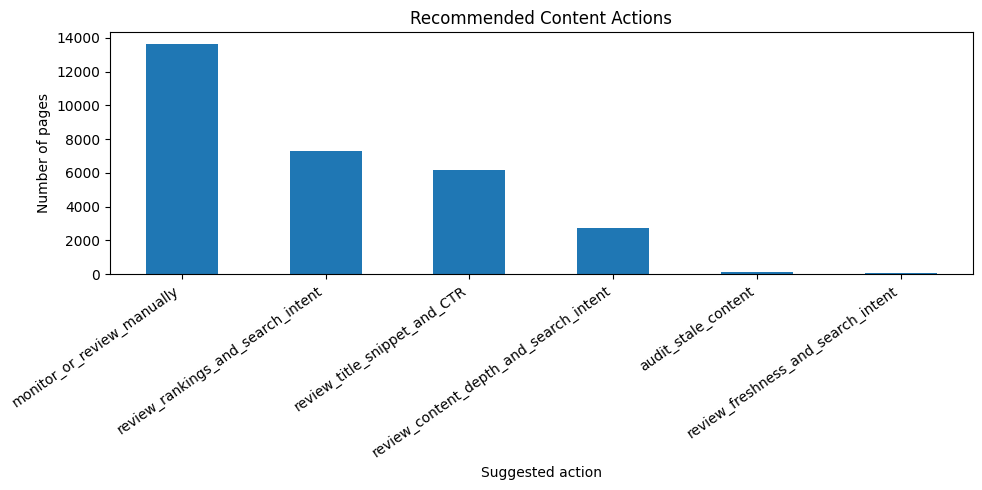

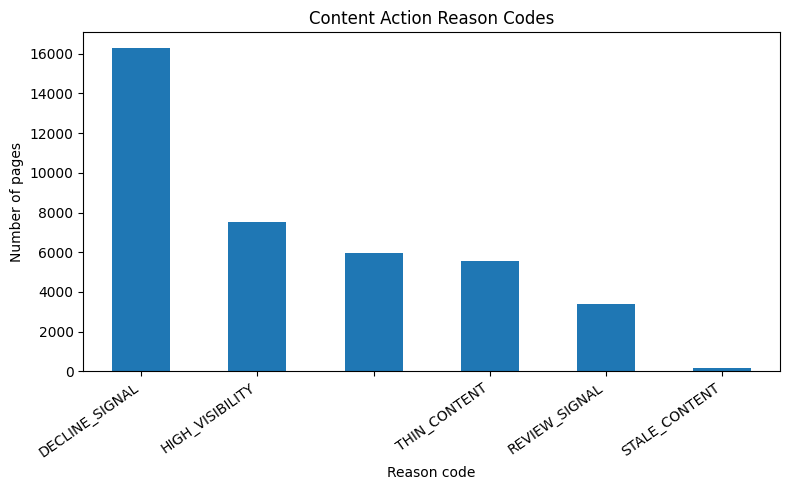

Queue: /content/ml-internship/work/outputs/content_action_queue.csv
Metrics: /content/ml-internship/work/outputs/w07_metrics.json
Figures:
/content/ml-internship/work/figures/w07_action_distribution.png
/content/ml-internship/work/figures/w07_reason_codes.png


In [10]:
import json
import matplotlib.pyplot as plt

OUTPUT = ROOT / "work/outputs"
FIGURES = ROOT / "work/figures"

OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Export ranked queue
queue_path = OUTPUT / "content_action_queue.csv"
action_queue.to_csv(queue_path, index=False)

# Export metrics
metrics = {
    "dataset_rows": int(len(df)),
    "queue_rows": int(len(action_queue)),
    "declining_pages": int(queue["declining"].sum()),
    "top_50_actions": action_queue.head(50)["suggested_action"].value_counts().to_dict(),
    "click_value_proxy_total": round(float(queue["click_value_proxy"].sum()), 2),
    "ranking_method": "transparent heuristic; not a validated predictive score",
}

metrics_path = OUTPUT / "w07_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

# Figure 1: Action distribution
action_counts = action_queue["suggested_action"].value_counts()

plt.figure(figsize=(10, 5))
action_counts.plot(kind="bar")
plt.title("Recommended Content Actions")
plt.xlabel("Suggested action")
plt.ylabel("Number of pages")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "w07_action_distribution.png", dpi=150)
plt.show()
plt.close()

# Figure 2: Reason-code distribution
reason_counts = (
    action_queue["reason_codes"]
    .str.split(";")
    .explode()
    .value_counts()
)

plt.figure(figsize=(8, 5))
reason_counts.plot(kind="bar")
plt.title("Content Action Reason Codes")
plt.xlabel("Reason code")
plt.ylabel("Number of pages")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "w07_reason_codes.png", dpi=150)
plt.show()
plt.close()

print("Queue:", queue_path)
print("Metrics:", metrics_path)
print("Figures:")
print(FIGURES / "w07_action_distribution.png")
print(FIGURES / "w07_reason_codes.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.